## Deep Learning Ex #1: MNIST + Input Gradients
---

### 📋 Architectural Overview
In this Example, we will explore interpretable deep learning by looking at the famous MNIST handwritten digit classificaiton task. 

To keep training efficient, we intentionally downsample our data. By scaling the standard images down, we drastically cut down parameters while maintaining class features:

| Metric / Layer | Standard MNIST Layout | Our Compact Tutorial Layout |
| :--- | :--- | :--- |
| **Data Footprint** | 60,000 Train / 10,000 Test | 10,000 Train / 2,000 Test (Subsampled) |
| **Image Resolution** | 28 × 28 = 784 pixels | 14 × 14 = 196 pixels |
| **Hidden Units** | 256 Layer 1 / 128 Layer 2 | 64 Layer 1 / 32 Layer 2 |
| **Total Parameters** | 235,146 weights/biases | ~15,000 weights/biases |
| **Colab Compute Time** | ~2–3 Minutes | ~10–15 Seconds |

### 🚀 Google Colab Note
For ease during the tutorial, we will use Google Colab. Unlike regular local setups **Google Colab comes with TensorFlow pre-installed**. This avoids environment compilation or package version discrepancies. (But if you are running this locally you might need to install other packages.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow Environment Confirmed. Version:", tf.__version__)

# Guarantee reproducible optimization paths
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow Environment Confirmed. Version: 2.21.0


## 1. Data Geometry: Stratification, Downsampling, and Vectorization

To fit our fast teaching tempo, we pull the MNIST database and create a **stratified subset** containing exactly 1,000 training examples and 200 testing examples per digit class ($0, 1, \dots, 9$). 

Mathematically, we cast each 28x28 matrix to a compact 14x14 grid using a bilinear resizing operator $$\mathcal{R}: \mathbb{R}^{28 \times 28} \to \mathbb{R}^{14 \times 14}.$$ We then map continuous pixel intensities from the integer grayscale boundary $[0, 255]$ down to the normalized real interval $[0, 1]$.

In [3]:
# 1. Pull the native data matrices
(x_train_full, g_train_full), (x_test_full, g_test_full) = keras.datasets.mnist.load_data()

# 2. Define stratified index sampling to ensure pristine class representation
def build_stratified_subset(images, labels, samples_per_class, seed=280):
    rng = np.random.default_rng(seed)
    selected_indices = np.concatenate([
        rng.choice(np.where(labels == digit)[0], size=samples_per_class, replace=False)
        for digit in range(10)
    ])
    rng.shuffle(selected_indices) # Break sequence blocks
    return images[selected_indices], labels[selected_indices]

x_train_raw, y_train = build_stratified_subset(x_train_full, g_train_full, samples_per_class=1000)
x_test_raw, y_test = build_stratified_subset(x_test_full, g_test_full, samples_per_class=200)

# 3. Bilinear Resolution Scaling (28x28 -> 14x14) via TensorFlow native tensors
x_train_14x14 = tf.image.resize(np.expand_dims(x_train_raw, axis=-1), (14, 14)).numpy().squeeze()
x_test_14x14 = tf.image.resize(np.expand_dims(x_test_raw, axis=-1), (14, 14)).numpy().squeeze()

# 4. Intensity Normalization [0, 255] -> [0, 1]
x_train = x_train_14x14 / 255.0
x_test = x_test_14x14 / 255.0

print(f"Downsampled Training Matrix Dimensions: {x_train.shape}")
print(f"Downsampled Testing Matrix Dimensions:  {x_test.shape}")

Downsampled Training Matrix Dimensions: (10000, 14, 14)
Downsampled Testing Matrix Dimensions:  (2000, 14, 14)


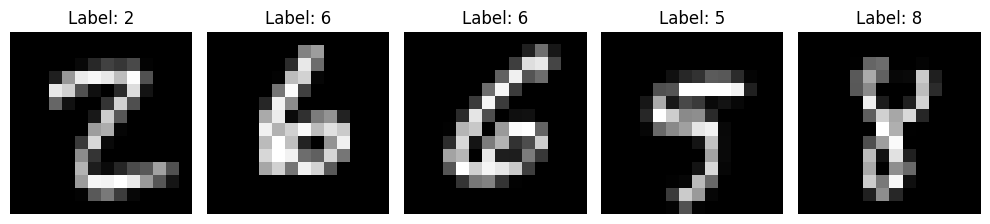

In [4]:
# Visualize a selection of downsampled training examples
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i in range(5):
    axes[i].imshow(x_train[i], cmap='gray')
    axes[i].set_title(f"Label: {y_train[i]}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## 2. Neural Networks as Composite Vector Maps

Let an input image be flattened into a vector $\mathbf{x}^{(0)} \in \mathbb{R}^{196}$. A Multilayer Perceptron (MLP) acts as a succession of affine transformations parameterized by weight matrices $\mathbf{W}^{(l)}$ and bias vectors $\mathbf{b}^{(l)}$, mapped through an element-wise scalar non-linearity $\sigma(\cdot)$:

$$\mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{x}^{(l-1)} + \mathbf{b}^{(l)}$$
$$\mathbf{x}^{(l)} = \sigma\left(\mathbf{z}^{(l)}\right)$$

For intermediate processing stages, we deploy the **Rectified Linear Unit (ReLU)** activation:
$$\sigma_{\text{ReLU}}(z) = \max(0, z)$$

For our terminal processing stage (Layer 3), we use a **Softmax vector operator** to project the unnormalized network outputs (logits) $\mathbf{z}^{(3)} \in \mathbb{R}^{10}$ onto a valid multinomial probability simplex:
$$S_c(\mathbf{x}^{(0)}) = \frac{\exp\left(z_c^{(3)}\right)}{\sum_{k=0}^{9} \exp\left(z_k^{(3)}\right)}.$$

Here $S_c(\mathbf{x}^{(0)})$ is interpreted as the network's calculated probability that the input sequence represents the digit class $c$.

In [5]:
def compile_compact_mlp():
    model = keras.Sequential([
        layers.Flatten(input_shape=(14, 14)),                         # Transform 14x14 array -> 196 vector
        layers.Dense(64, activation='relu', name='Hidden_Layer_1'),   # W1: (196 x 64), b1: (64,)
        layers.Dense(32, activation='relu', name='Hidden_Layer_2'),   # W2: (64 x 32),  b2: (32,)
        layers.Dense(10, activation='softmax', name='Output_Layer')   # W3: (32 x 10),  b3: (10,)
    ], name="Compact_Pedagogical_MLP")
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp_model = compile_compact_mlp()
mlp_model.summary()

/Users/suzannesindi/miniforge3/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Compact_Pedagogical_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 196)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_1 (Dense)          │ (None, 64)             │        12,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,018 (58.66 KB)

 Trainable params: 15,018 (58.66 KB)

 Non-trainable params: 0 (0.00 B)

Executing fast model optimization routine...
Epoch 1/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7717 - loss: 0.7708 - val_accuracy: 0.9035 - val_loss: 0.3358
Epoch 2/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 599us/step - accuracy: 0.9169 - loss: 0.2949 - val_accuracy: 0.9230 - val_loss: 0.2644
Epoch 3/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step - accuracy: 0.9347 - loss: 0.2242 - val_accuracy: 0.9320 - val_loss: 0.2203
Epoch 4/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step - accuracy: 0.9484 - loss: 0.1768 - val_accuracy: 0.9435 - val_loss: 0.1960
Epoch 5/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step - accuracy: 0.9579 - loss: 0.1429 - val_accuracy: 0.9475 - val_loss: 0.1861
Epoch 6/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step - accuracy: 0.9662 - loss: 0.1167 - val_accuracy: 0.9490 - val_loss: 0.1779
Epoch 7/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - accuracy: 0.9730 - loss: 0.0974 - val_accuracy: 0.9510 - val_loss: 0.1816
Epoch 8/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step - accurac

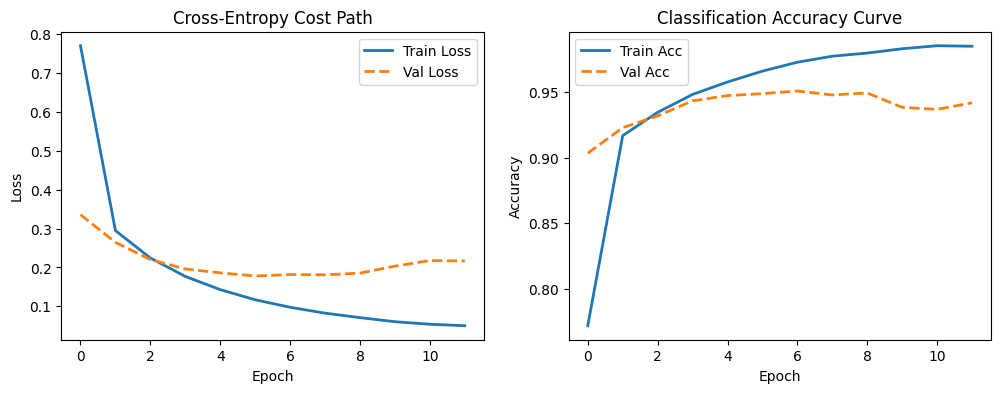

In [6]:
# Run optimization across 12 training periods
print("Executing fast model optimization routine...")
history = mlp_model.fit(
    x_train, y_train,
    epochs=12,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

# Plot training outcomes to inspect convergence behavior
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'], label='Train Loss', lw=2)
ax1.plot(history.history['val_loss'], label='Val Loss', lw=2, linestyle='--')
ax1.set_title("Cross-Entropy Cost Path")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(history.history['accuracy'], label='Train Acc', lw=2)
ax2.plot(history.history['val_accuracy'], label='Val Acc', lw=2, linestyle='--')
ax2.set_title("Classification Accuracy Curve")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
plt.show()

## 3. Post-Hoc Sensitivity Analysis via Input Gradients (Saliency Maps)

Once our network is optimized, we treat it as a static, fixed vector mapping $F: \mathbb{R}^{14 \times 14} \to \mathbb{R}^{10}$. To understand why a model classifies a specific image as belonging to class $c$, we analyze its local sensitivity to variations in the input data.

Using a first-order multivariate **Taylor Series expansion**, we approximate how changes to individual pixel elements impact the final output score. If we add a small perturbation vector $\mathbf{\Delta x}$ to a given baseline input image $\mathbf{x}_0$, the change in the score for target class $c$ is:

$$S_c(\mathbf{x}_0 + \mathbf{\Delta x}) \approx S_c(\mathbf{x}_0) + \left[ \nabla_{\mathbf{x}} S_c(\mathbf{x}_0) \right]^T \mathbf{\Delta x}$$

The input gradient vector $\nabla_{\mathbf{x}} S_c(\mathbf{x}_0) \in \mathbb{R}^{14 \times 14}$ represents the first-order partial derivatives of the class score with respect to each input coordinate:

$$\nabla_{\mathbf{x}} S_c(\mathbf{x}_0) = \left[ \frac{\partial S_c(\mathbf{x}_0)}{\partial x_{i,j}} \right]$$

A higher magnitude for a partial derivative $|\frac{\partial S_c}{\partial x_{i,j}}|$ implies that changing the intensity of pixel $(i,j)$ will significantly change the model's output prediction. By computing this gradient and taking its absolute value, we construct a **Vanilla Saliency Map**, which visually highlights the parts of the image that the network relies on most to make its decision.

In [7]:
def compute_input_saliency(model, image, target_class):
    """
    Computes the absolute input gradient vector for a single image matrix
    using TensorFlow's programmatic automatic differentiation engine.
    """
    # 1. Cast the raw 14x14 numpy array into a continuous float32 Tensor
    image_tensor = tf.convert_to_tensor(image, dtype=tf.float32)
    
    # 2. Add the singleton batch dimension required by standard Keras layers: (14, 14) -> (1, 14, 14)
    image_tensor = tf.expand_dims(image_tensor, axis=0)
    
    # 3. Monitor the input tensor coordinates during the forward computation pass
    with tf.GradientTape() as tape:
        tape.watch(image_tensor)
        
        # Forward pass: extract prediction vector
        predictions = model(image_tensor)
        
        # Isolate the scalar activation corresponding to our target class
        class_score = predictions[0, target_class]
        
    # 4. Backward pass: evaluate the partial derivative matrix d(score) / d(image)
    gradient = tape.gradient(class_score, image_tensor)
    
    # 5. Drop batch dimension and apply absolute valuation operator
    absolute_saliency = tf.squeeze(tf.abs(gradient)).numpy()
    
    return absolute_saliency

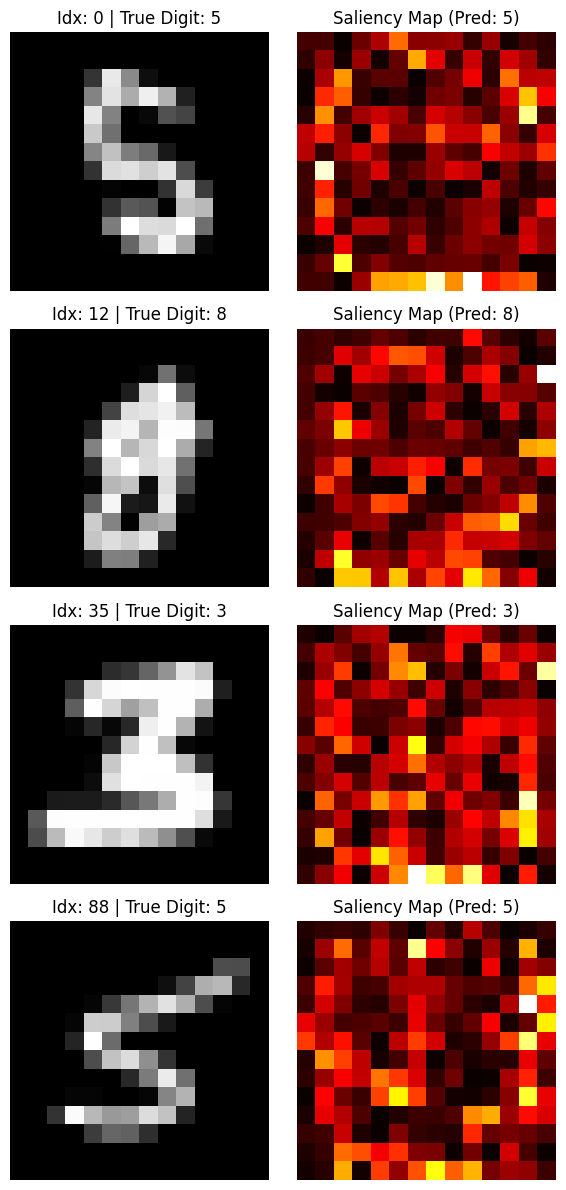

In [8]:
# Select a series of target testing images to inspect
sample_indices = [0, 12, 35, 88] 

fig, axes = plt.subplots(len(sample_indices), 2, figsize=(6, 3 * len(sample_indices)))

for step, idx in enumerate(sample_indices):
    test_img = x_test[idx]
    true_label = y_test[idx]
    
    # Run the image forward through our network to grab the model's prediction
    pred_probabilities = mlp_model.predict(tf.expand_dims(test_img, axis=0), verbose=0)
    predicted_class = np.argmax(pred_probabilities)
    
    # Compute the saliency map for the predicted class
    saliency_map = compute_input_saliency(mlp_model, test_img, predicted_class)
    
    # Panel A: Render raw image
    axes[step, 0].imshow(test_img, cmap='gray')
    axes[step, 0].set_title(f"Idx: {idx} | True Digit: {true_label}")
    axes[step, 0].axis('off')
    
    # Panel B: Render corresponding local gradient sensitivity heat map
    im = axes[step, 1].imshow(saliency_map, cmap='hot')
    axes[step, 1].set_title(f"Saliency Map (Pred: {predicted_class})")
    axes[step, 1].axis('off')

plt.tight_layout()
plt.show()

## Those are helpful but let's try something different


In [11]:
def compile_compact_cnn():
    model = keras.Sequential([
        # 1. Reshape the 14x14 matrix to include a 1-channel 'color' dimension (14, 14, 1)
        # This is a strict requirement for convolutional layers
        layers.Reshape((14, 14, 1), input_shape=(14, 14)),
        
        # 2. Convolutional Layer: 8 localized filters of size 3x3
        # This forces spatial weight-sharing across 2D space.
        layers.Conv2D(8, kernel_size=(3, 3), activation='relu', name='Conv_Layer_1'),
        
        # 3. Max Pooling: Downsample 2x2 blocks to extract translation-invariant features
        layers.MaxPooling2D(pool_size=(2, 2), name='Max_Pool_1'),
        
        # 4. Flatten the remaining feature maps into a vector for classification
        layers.Flatten(),
        
        # 5. Hidden Dense Layer for feature mixing
        layers.Dense(32, activation='relu', name='Hidden_Dense'),
        
        # 6. Final Softmax Output Layer for the 10 digit classes
        layers.Dense(10, activation='softmax', name='Output_Layer')
    ], name="Compact_Pedagogical_CNN")
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Instantiate and check the parameters
cnn_model = compile_compact_cnn()
cnn_model.summary()

/Users/suzannesindi/miniforge3/lib/python3.12/site-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Compact_Pedagogical_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 14, 14, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_Layer_1 (Conv2D)           │ (None, 12, 12, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_1 (MaxPooling2D)       │ (None, 6, 6, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Dense (Dense)            │ (None, 32)             │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,658 (37.73 KB)

 Trainable params: 9,658 (37.73 KB)

 Non-trainable params: 0 (0.00 B)

Executing fast CNN model optimization routine...
Epoch 1/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7481 - loss: 0.8831 - val_accuracy: 0.8970 - val_loss: 0.3649
Epoch 2/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9174 - loss: 0.2814 - val_accuracy: 0.9340 - val_loss: 0.2235
Epoch 3/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9416 - loss: 0.2050 - val_accuracy: 0.9480 - val_loss: 0.1761
Epoch 4/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9533 - loss: 0.1625 - val_accuracy: 0.9545 - val_loss: 0.1495
Epoch 5/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9600 - loss: 0.1366 - val_accuracy: 0.9575 - val_loss: 0.1319
Epoch 6/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9656 - loss: 0.1177 - val_accuracy: 0.9600 - val_loss: 0.1195
Epoch 7/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9686 - loss: 0.1034 - val_accuracy: 0.9640 - val_loss: 0.1098
Epoch 8/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9710 

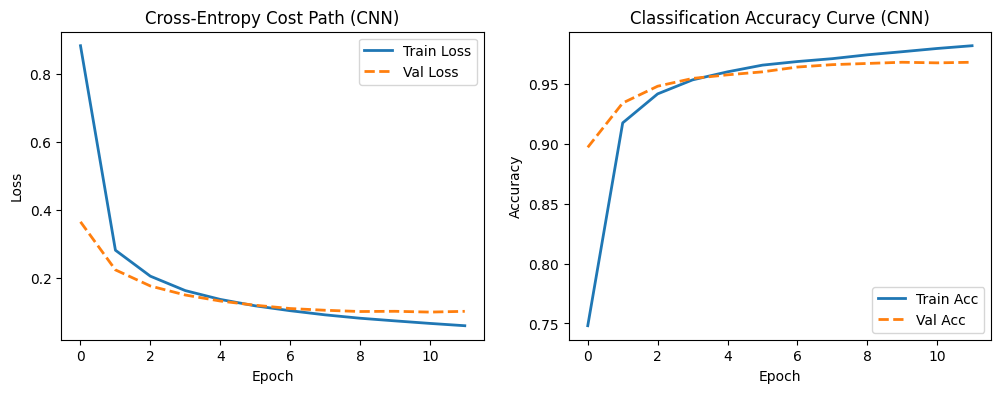

In [12]:
# Run optimization across 12 training periods using the new CNN architecture
print("Executing fast CNN model optimization routine...")
history = cnn_model.fit(
    x_train, y_train,
    epochs=12,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

# Plot training outcomes to inspect convergence behavior
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'], label='Train Loss', lw=2)
ax1.plot(history.history['val_loss'], label='Val Loss', lw=2, linestyle='--')
ax1.set_title("Cross-Entropy Cost Path (CNN)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(history.history['accuracy'], label='Train Acc', lw=2)
ax2.plot(history.history['val_accuracy'], label='Val Acc', lw=2, linestyle='--')
ax2.set_title("Classification Accuracy Curve (CNN)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
plt.show()

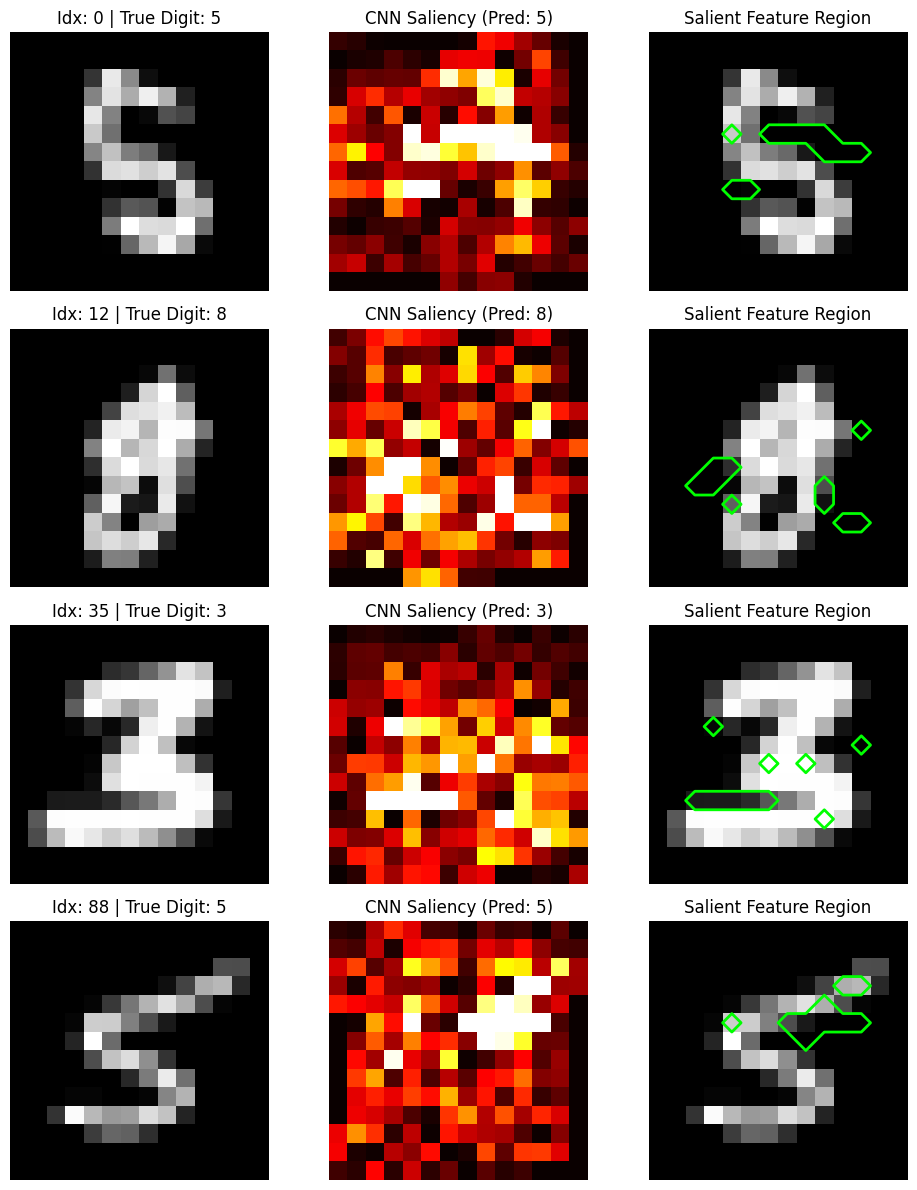

In [14]:
# Select the exact same target testing images to inspect
sample_indices = [0, 12, 35, 88] 

# Shift to 3 columns: Raw Image, Saliency Heatmap, Saliency Overlay
fig, axes = plt.subplots(len(sample_indices), 3, figsize=(10, 3 * len(sample_indices)))

for step, idx in enumerate(sample_indices):
    test_img = x_test[idx]
    true_label = y_test[idx]
    
    # 1. Forward pass through our CNN to get the prediction
    pred_probabilities = cnn_model.predict(tf.expand_dims(test_img, axis=0), verbose=0)
    predicted_class = np.argmax(pred_probabilities)
    
    # 2. Compute the raw saliency map for the predicted class using the CNN
    saliency_map = compute_input_saliency(cnn_model, test_img, predicted_class)
    
    # 3. Robust scaling for the heatmap (clip at 95th percentile)
    v_max = np.percentile(saliency_map, 95)
    clipped_saliency = np.clip(saliency_map, 0, v_max)
    normalized_saliency = clipped_saliency / (v_max + 1e-8)
    
    # 4. Create a binary mask for the top 5% of important pixels (above 95th percentile)
    # This identifies the region of high local sensitivity
    importance_threshold = np.percentile(saliency_map, 95)
    importance_mask = (saliency_map >= importance_threshold).astype(float)
    
    # --- Column 1: Raw Normalized Image ---
    axes[step, 0].imshow(test_img, cmap='gray')
    axes[step, 0].set_title(f"Idx: {idx} | True Digit: {true_label}")
    axes[step, 0].axis('off')
    
    # --- Column 2: Saliency Heatmap ---
    axes[step, 1].imshow(normalized_saliency, cmap='hot')
    axes[step, 1].set_title(f"CNN Saliency (Pred: {predicted_class})")
    axes[step, 1].axis('off')
    
    # --- Column 3: Original Image with Green Region Outline ---
    axes[step, 2].imshow(test_img, cmap='gray')
    # Use contour to draw a sharp, green outline tracing the boundary of our importance mask
    # levels=[0.5] draws the line exactly where the mask transitions from 0 to 1
    axes[step, 2].contour(importance_mask, levels=[0.5], colors='lime', linewidths=2)
    axes[step, 2].set_title("Salient Feature Region")
    axes[step, 2].axis('off')

plt.tight_layout()
plt.show()

## 4. Interactive Discussion: Interpreting Sensitivity in Applied Models

### Classroom Questions & Exercises:
1. **The Spatial Distribution of Saliency:** Look at the generated heatmaps. Notice how the bright (highly sensitive) pixels concentrate along structural boundaries and central intersections rather than empty background space. Why does this highlight the difference between background noise and actual data coordinates?
2. **Analysis of Misclassifications (Class Exercise):** Locate an index where the network misclassifies an input (e.g., a stylized `4` mistaken for a `9`). Modify the inspection script above to calculate the saliency map for the *wrong* choice versus the *right* choice. How does the shifting gradient map reveal exactly what geometric traits misled the network?
3. **Connection to Parametric Sensitivity Analysis:** For applied mathematics students, how does computing $\nabla_{\mathbf{x}} S_c(\mathbf{x}_0)$ for an image classification task mirror computing parametric sensitivities or Jacobian matrices $\mathbf{J}$ within continuous biological modeling systems (such as metabolic pathway networks or epidemiological ODEs)?